<a href="https://colab.research.google.com/github/habibiputrar/DeepLearning_B_2411531001_Habibi-Putra-Rizqullah/blob/main/Praktikum2/Tugas_Praktikum2_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Individu Minggu 2
## Perbandingan Kedalaman CNN pada Dataset MNIST

**Nama:** Habibi Putra Rizqullah  
**NIM:** 2411531001

Eksperimen ini membandingkan model dasar dengan dua lapisan konvolusi dan model modifikasi dengan tiga lapisan konvolusi. Model kedua juga memakai kernel 5 × 5 pada lapisan pertama sesuai arahan tugas.


### 1. Menyiapkan library dan perangkat

Library digunakan untuk pengolahan data, pembuatan CNN, pengukuran waktu, visualisasi, dan penyusunan tabel hasil. Seed disamakan agar perbandingan kedua model lebih adil.


In [13]:
import copy
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Perangkat yang digunakan: {device}")


Perangkat yang digunakan: cpu


### 2. Memuat dataset

Dataset, normalisasi, batch size, dan jumlah epoch dibuat sama untuk kedua model. Dengan begitu, perbedaan hasil lebih berkaitan dengan arsitektur model, bukan pengaturan data yang berbeda.


In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
testset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

trainloader = DataLoader(
    trainset, batch_size=64, shuffle=True, num_workers=0,
    pin_memory=torch.cuda.is_available()
)
testloader = DataLoader(
    testset, batch_size=64, shuffle=False, num_workers=0,
    pin_memory=torch.cuda.is_available()
)

EPOCHS = 5
LEARNING_RATE = 0.001

print(f"Data latih: {len(trainset):,}")
print(f"Data uji  : {len(testset):,}")


Data latih: 60,000
Data uji  : 10,000


### 3. Membuat model CNN 1 sebagai baseline

CNN 1 mengikuti model praktikum: dua konvolusi 3 × 3, dua max pooling, lalu dua fully connected layer. Model ini menjadi pembanding untuk melihat dampak penambahan kedalaman.


In [15]:
class CNNBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


### 4. Membuat CNN 2 dengan tiga lapisan konvolusi

CNN 2 memakai kernel 5 × 5 pada lapisan pertama dan menambah satu lapisan konvolusi. Setelah tiga kali pooling, ukuran feature map menjadi 3 × 3. Dropout ditambahkan untuk membantu mengurangi risiko overfitting.


In [16]:
class CNNDeeper(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 3 * 3, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


### 5. Memeriksa ukuran keluaran model

Satu batch buatan dimasukkan ke kedua model. Pemeriksaan ini memastikan dimensi pada fully connected layer sudah sesuai sebelum training dilakukan.


In [17]:
dummy_input = torch.randn(4, 1, 28, 28).to(device)

baseline_check = CNNBaseline().to(device)
deeper_check = CNNDeeper().to(device)

print("Output CNN 1:", baseline_check(dummy_input).shape)
print("Output CNN 2:", deeper_check(dummy_input).shape)

del baseline_check, deeper_check, dummy_input
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Output CNN 1: torch.Size([4, 10])
Output CNN 2: torch.Size([4, 10])


### 6. Membuat fungsi evaluasi

Fungsi ini menghitung rata-rata loss dan akurasi. Mode evaluasi diperlukan agar dropout pada CNN 2 tidak aktif ketika model diuji.


In [18]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, 100 * correct / total


### 7. Membuat fungsi eksperimen

Fungsi berikut melatih satu model, mencatat metrik setiap epoch, dan mengukur waktu training. Model dengan akurasi testing terbaik disimpan agar evaluasi akhir tidak hanya bergantung pada epoch terakhir.


In [19]:
def run_experiment(model, model_name, trainloader, testloader, epochs, device):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history = {
        "train_loss": [], "test_loss": [],
        "train_accuracy": [], "test_accuracy": []
    }
    best_accuracy = -1.0
    best_state = None
    start_time = time.perf_counter()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in trainloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total
        test_loss, test_accuracy = evaluate(model, testloader, criterion, device)

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_accuracy"].append(train_accuracy)
        history["test_accuracy"].append(test_accuracy)

        if test_accuracy > best_accuracy:
            best_accuracy = test_accuracy
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"{model_name} | Epoch {epoch + 1}/{epochs} | "
            f"train acc: {train_accuracy:.2f}% | test acc: {test_accuracy:.2f}%"
        )

    training_time = time.perf_counter() - start_time
    model.load_state_dict(best_state)
    final_train_loss, final_train_accuracy = evaluate(
        model, trainloader, criterion, device
    )
    final_test_loss, final_test_accuracy = evaluate(
        model, testloader, criterion, device
    )

    result = {
        "model": model,
        "history": history,
        "train_accuracy": final_train_accuracy,
        "test_accuracy": final_test_accuracy,
        "training_time": training_time
    }
    return result


### 8. Menjalankan kedua eksperimen

Kedua model dilatih menggunakan jumlah epoch dan learning rate yang sama. Waktu dapat berbeda bergantung pada CPU atau GPU yang digunakan.


In [8]:
torch.manual_seed(SEED)
baseline_result = run_experiment(
    CNNBaseline(), "CNN 1", trainloader, testloader, EPOCHS, device
)

torch.manual_seed(SEED)
deeper_result = run_experiment(
    CNNDeeper(), "CNN 2", trainloader, testloader, EPOCHS, device
)


CNN 1 | Epoch 1/5 | train acc: 93.68% | test acc: 98.08%
CNN 1 | Epoch 2/5 | train acc: 98.22% | test acc: 98.64%
CNN 1 | Epoch 3/5 | train acc: 98.69% | test acc: 98.72%
CNN 1 | Epoch 4/5 | train acc: 99.00% | test acc: 98.74%
CNN 1 | Epoch 5/5 | train acc: 99.23% | test acc: 98.92%
CNN 2 | Epoch 1/5 | train acc: 92.39% | test acc: 98.63%
CNN 2 | Epoch 2/5 | train acc: 98.11% | test acc: 98.96%
CNN 2 | Epoch 3/5 | train acc: 98.62% | test acc: 98.99%
CNN 2 | Epoch 4/5 | train acc: 98.86% | test acc: 99.12%
CNN 2 | Epoch 5/5 | train acc: 99.05% | test acc: 99.12%


### 9. Menyusun tabel hasil

Tabel dibuat langsung dari hasil training sehingga nilai akurasi dan waktu tidak diisi secara manual. Kolom catatan menjelaskan perbedaan utama arsitektur.


In [9]:
comparison_table = pd.DataFrame([
    {
        "Eksperimen": "CNN_1",
        "Jumlah Layer": "2 conv",
        "Akurasi Training (%)": baseline_result["train_accuracy"],
        "Akurasi Testing (%)": baseline_result["test_accuracy"],
        "Waktu Training (s)": baseline_result["training_time"],
        "Catatan": "Baseline, kernel 3×3"
    },
    {
        "Eksperimen": "CNN_2",
        "Jumlah Layer": "3 conv",
        "Akurasi Training (%)": deeper_result["train_accuracy"],
        "Akurasi Testing (%)": deeper_result["test_accuracy"],
        "Waktu Training (s)": deeper_result["training_time"],
        "Catatan": "Kernel awal 5×5 dan dropout"
    }
])

numeric_columns = [
    "Akurasi Training (%)", "Akurasi Testing (%)", "Waktu Training (s)"
]
comparison_table[numeric_columns] = comparison_table[numeric_columns].round(2)
comparison_table


,Eksperimen,Jumlah Layer,Akurasi Training (%),Akurasi Testing (%),Waktu Training (s),Catatan
0,CNN_1,2 conv,99.55,98.92,265.44,"Baseline, kernel 3×3"
1,CNN_2,3 conv,99.40,99.12,321.79,Kernel awal 5×5 dan dropout


### 10. Membandingkan grafik kedua model

Grafik menampilkan akurasi dan loss testing pada setiap epoch. Dari sini dapat dilihat model mana yang belajar lebih cepat dan apakah peningkatannya stabil.


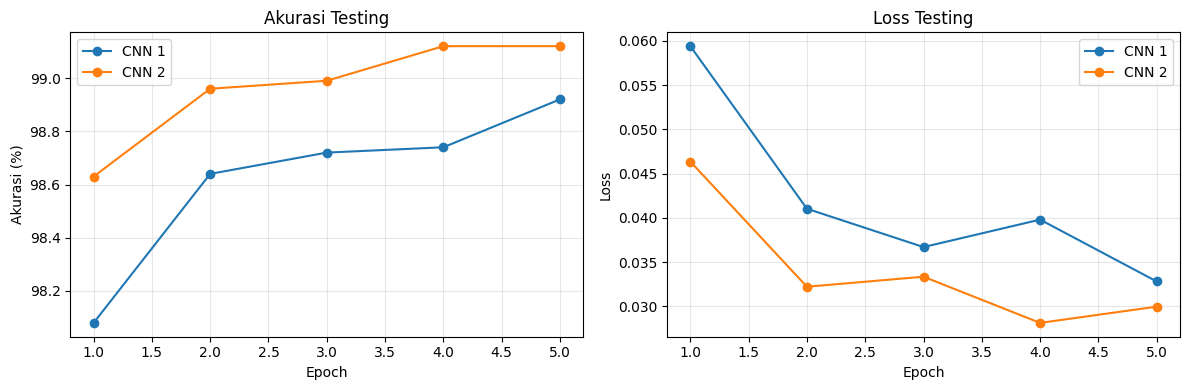

In [10]:
epoch_numbers = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    epoch_numbers, baseline_result["history"]["test_accuracy"],
    marker="o", label="CNN 1"
)
axes[0].plot(
    epoch_numbers, deeper_result["history"]["test_accuracy"],
    marker="o", label="CNN 2"
)
axes[0].set_title("Akurasi Testing")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Akurasi (%)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    epoch_numbers, baseline_result["history"]["test_loss"],
    marker="o", label="CNN 1"
)
axes[1].plot(
    epoch_numbers, deeper_result["history"]["test_loss"],
    marker="o", label="CNN 2"
)
axes[1].set_title("Loss Testing")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 11. Membuat kesimpulan berdasarkan hasil

Kesimpulan di bawah dibuat dari selisih akurasi dan waktu yang benar-benar diperoleh saat notebook dijalankan. Dengan cara ini, pembahasan tetap sesuai hasil eksperimen pada perangkat yang digunakan.


In [11]:
accuracy_difference = (
    deeper_result["test_accuracy"] - baseline_result["test_accuracy"]
)
time_difference = (
    deeper_result["training_time"] - baseline_result["training_time"]
)
baseline_gap = (
    baseline_result["train_accuracy"] - baseline_result["test_accuracy"]
)
deeper_gap = (
    deeper_result["train_accuracy"] - deeper_result["test_accuracy"]
)

if accuracy_difference > 0:
    accuracy_statement = (
        f"CNN 2 lebih akurat {accuracy_difference:.2f} poin persentase daripada CNN 1."
    )
elif accuracy_difference < 0:
    accuracy_statement = (
        f"CNN 2 lebih rendah {abs(accuracy_difference):.2f} poin persentase daripada CNN 1."
    )
else:
    accuracy_statement = "Kedua model menghasilkan akurasi testing yang sama."

if time_difference > 0:
    time_statement = f"CNN 2 membutuhkan waktu {time_difference:.2f} detik lebih lama."
else:
    time_statement = f"CNN 2 selesai {abs(time_difference):.2f} detik lebih cepat."

print("Kesimpulan:")
print(accuracy_statement)
print(time_statement)
print(f"Gap train-test CNN 1: {baseline_gap:.2f} poin persentase.")
print(f"Gap train-test CNN 2: {deeper_gap:.2f} poin persentase.")
print(
    "Penambahan lapisan memberi kapasitas ekstraksi fitur yang lebih besar, "
    "tetapi juga menambah beban komputasi. Karena itu, model yang lebih dalam "
    "tidak otomatis menjadi pilihan paling efisien."
)


Kesimpulan:
CNN 2 lebih akurat 0.20 poin persentase daripada CNN 1.
CNN 2 membutuhkan waktu 56.36 detik lebih lama.
Gap train-test CNN 1: 0.63 poin persentase.
Gap train-test CNN 2: 0.28 poin persentase.
Penambahan lapisan memberi kapasitas ekstraksi fitur yang lebih besar, tetapi juga menambah beban komputasi. Karena itu, model yang lebih dalam tidak otomatis menjadi pilihan paling efisien.


### 12. Menampilkan prediksi CNN 2

Model modifikasi digunakan untuk memprediksi sepuluh gambar uji. Warna judul membantu membedakan hasil benar dan salah.


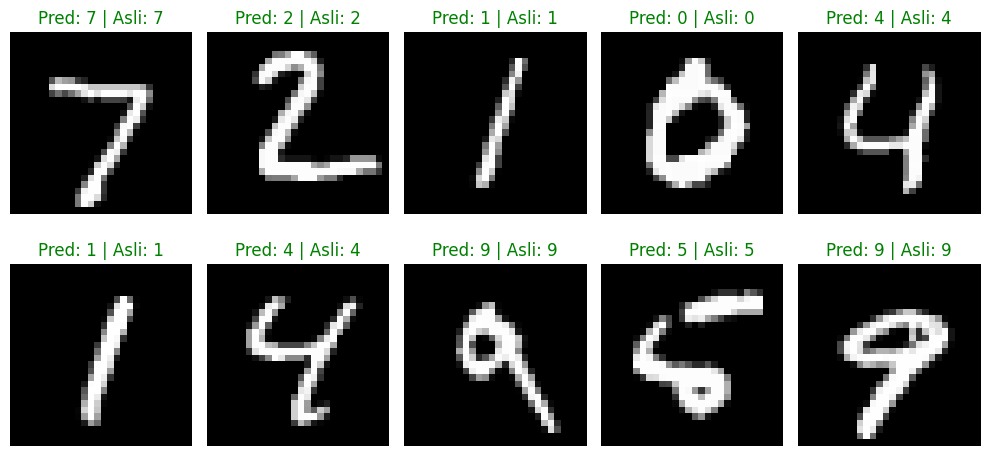

In [12]:
model = deeper_result["model"]
model.eval()
images, labels = next(iter(testloader))

with torch.no_grad():
    predictions = model(images.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for index, ax in enumerate(axes.flat):
    image = images[index].squeeze().numpy() * 0.5 + 0.5
    is_correct = predictions[index].item() == labels[index].item()
    ax.imshow(image, cmap="gray")
    ax.set_title(
        f"Pred: {predictions[index].item()} | Asli: {labels[index].item()}",
        color="green" if is_correct else "red"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


### Pembahasan singkat

CNN 2 memiliki kemampuan mempelajari fitur yang lebih bertingkat karena menggunakan tiga lapisan konvolusi. Kernel 5 × 5 pada lapisan pertama melihat wilayah citra yang lebih luas, sedangkan lapisan berikutnya menyusun fitur sederhana menjadi pola yang lebih kompleks. Konsekuensinya, jumlah operasi bertambah dan waktu training dapat menjadi lebih lama. Hasil akhir tetap ditentukan oleh akurasi testing, gap train-test, serta waktu yang muncul pada tabel.

### Jawaban pertanyaan reflektif

1. **Mengapa CNN lebih baik dibanding MLP untuk citra?**  
   CNN mempertahankan informasi posisi piksel dan memakai filter yang sama pada berbagai bagian gambar. MLP meratakan gambar sejak awal sehingga hubungan spasial lebih sulit dimanfaatkan dan jumlah parameternya cenderung lebih besar.

2. **Apa fungsi pooling layer dalam CNN?**  
   Pooling memperkecil feature map, mengurangi beban komputasi, dan mempertahankan informasi yang dianggap penting. Model juga menjadi lebih tahan terhadap perubahan kecil pada posisi objek.

3. **Bagaimana pengaruh ukuran kernel terhadap hasil konvolusi?**  
   Kernel yang lebih besar mencakup area citra lebih luas dalam satu operasi, tetapi memakai lebih banyak parameter dan komputasi. Kernel kecil lebih hemat dan dapat ditumpuk untuk memperoleh receptive field yang lebih luas secara bertahap.
